<a href="https://colab.research.google.com/github/MehulShukla-git/Movie_Recommendation_System/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LOGISTIC REGRESSION**

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [82]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
df = pd.read_csv('/content/drive/MyDrive/movies_metadata.csv', header=None)

df = df[0].str.split(',', expand=True)

df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

print(df.columns)

Index([                'adult', 'belongs_to_collection',
                      'budget',                'genres',
                    'homepage',                    'id',
                     'imdb_id',     'original_language',
              'original_title',              'overview',
       ...
                          None,                    None,
                          None,                    None,
                          None,                    None,
                          None,                    None,
                          None,                    None],
      dtype='object', name=0, length=164)


In [84]:
df = df[['title','overview','genres','tagline','vote_average','popularity']]

df = df.dropna(subset=['title'])

df['overview'] = df['overview'].fillna('')
df['tagline'] = df['tagline'].fillna('')

In [85]:
import ast

def extract_genres(x):
    try:
        return " ".join([i['name'] for i in ast.literal_eval(x)])
    except:
        return ""

df['genres'] = df['genres'].apply(extract_genres)

df['tags'] = df['overview'] + " " + df['genres'] + " " + df['tagline']

In [86]:
import nltk, re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

df['tags'] = df['tags'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [87]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['tags'])


In [88]:
# Target
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce').fillna(0)
y = df['vote_average'].apply(lambda x: 1 if x >= 6 else 0)

X_dense = X.toarray()

Logistic Regression Model

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

# 70-30 Split
X_train, X_test, y_train, y_test = train_test_split(
    X_dense, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)

print("===== LOGISTIC REGRESSION (70-30) =====")
print("Accuracy :", acc)
print("Accuracy % :", acc * 100)
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

===== LOGISTIC REGRESSION (70-30) =====
Accuracy : 0.9589141599413059
Accuracy % : 95.8914159941306
Precision: 0.8768233387358185
Recall   : 0.5278048780487805
F1 Score : 0.658952496954933
ROC-AUC  : 0.8841023209914766


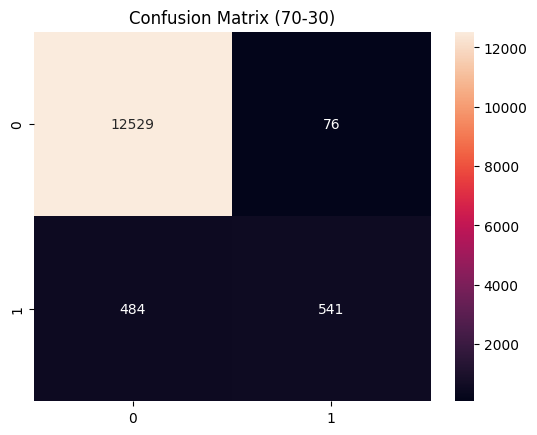

In [90]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (70-30)")
plt.show()

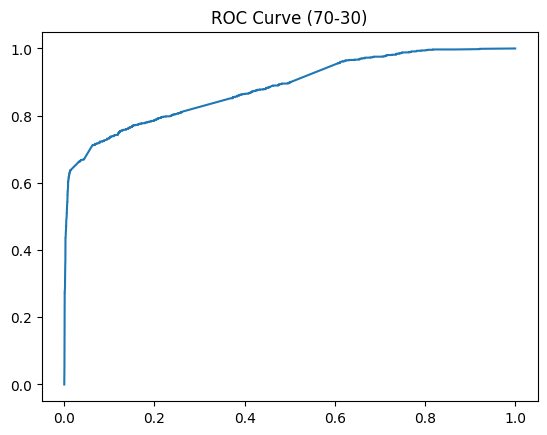

In [91]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve (70-30)")
plt.show()

In [92]:
# 80-20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X_dense, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred)

print("\n===== LOGISTIC REGRESSION (80-20) =====")
print("Accuracy :", acc)
print("Accuracy % :", acc * 100)
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))


===== LOGISTIC REGRESSION (80-20) =====
Accuracy : 0.9603829646748102
Accuracy % : 96.03829646748102
Precision: 0.8679245283018868
Recall   : 0.5476190476190477
F1 Score : 0.6715328467153284
ROC-AUC  : 0.8921166320063381


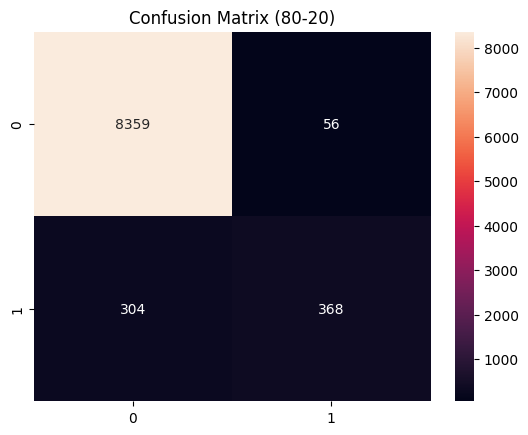

In [93]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (80-20)")
plt.show()

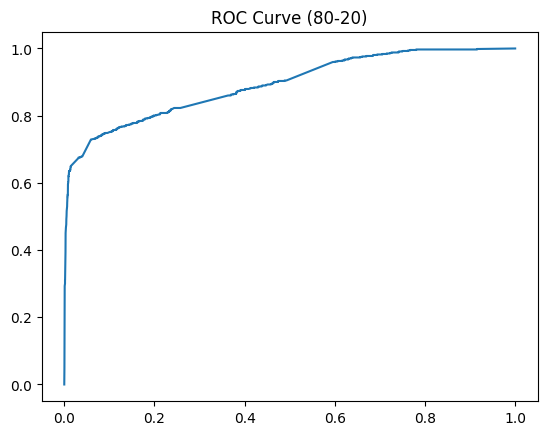

In [94]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr)
plt.title("ROC Curve (80-20)")
plt.show()